# Segmentación Semántica de Personas con PyTorch

**Proyecto 01 — Redes Neuronales (USFQ)**  
**Autor:** [Tu nombre]  
**Fecha:** Marzo 2026

---

## Objetivo

Desarrollar un modelo de segmentación semántica basado en una arquitectura **U-Net** implementada en **PyTorch** para separar personas del fondo en imágenes. El modelo será entrenado con el _Human Segmentation Dataset_ y evaluado tanto en imágenes estáticas como en video.

---

## Repositorio del Dataset

**Fuente:** [Human Segmentation Dataset — Vikram Shenoy](https://github.com/VikramShenoy97/Human-Segmentation-Dataset)  

El dataset contiene:
- **Training_Images/**: Imágenes de entrada en formato `.jpg`
- **Ground_Truth/**: Máscaras binarias de segmentación en formato `.png`

Las imágenes deben colocarse en la carpeta `data/` del proyecto conservando la estructura original.

---
## 1. Configuración del Entorno e Importación de Librerías

In [1]:
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchinfo import summary

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Dispositivo
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")

# Rutas del proyecto
ROOT_DIR   = os.path.dirname(os.path.abspath("__file__"))
DATA_DIR   = os.path.join(ROOT_DIR, "data")
IMG_DIR    = os.path.join(DATA_DIR, "Training_Images")
MASK_DIR   = os.path.join(DATA_DIR, "Ground_Truth")
MODEL_DIR  = os.path.join(ROOT_DIR, "models")
OUTPUT_DIR = os.path.join(ROOT_DIR, "outputs")
VIDEO_DIR  = os.path.join(ROOT_DIR, "videos")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "videos"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "samples"), exist_ok=True)

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 6)

Dispositivo: cpu


---
## 2. Análisis Exploratorio del Conjunto de Datos (EDA)

En esta sección se exploran las propiedades del dataset: cantidad de muestras, distribución de resoluciones, balance de clases en las máscaras y visualización de ejemplos representativos.

In [2]:
# --- 2.1  Listar y contar muestras ---
image_paths = sorted(glob.glob(os.path.join(IMG_DIR, "*.jpg")))
mask_paths  = sorted(glob.glob(os.path.join(MASK_DIR, "*.png")))

print(f"Imágenes de entrenamiento: {len(image_paths)}")
print(f"Máscaras Ground Truth   : {len(mask_paths)}")

assert len(image_paths) == len(mask_paths), "¡Discrepancia entre imágenes y máscaras!"

Imágenes de entrenamiento: 290
Máscaras Ground Truth   : 290


             width       height
count   290.000000   290.000000
mean    553.506897   494.348276
std     247.001243   217.334432
min     183.000000   145.000000
25%     450.000000   300.000000
50%     480.000000   480.000000
75%     640.000000   640.000000
max    1500.000000  1498.000000


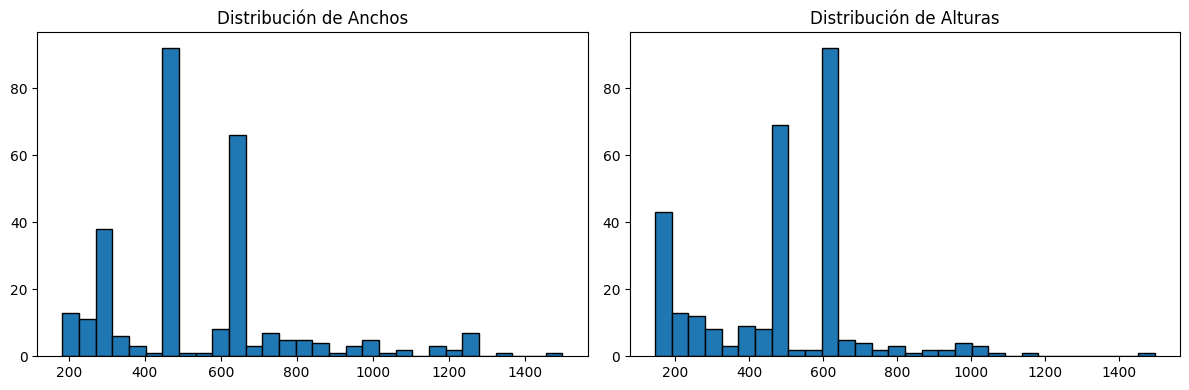

In [3]:
# --- 2.2  Distribución de resoluciones ---
widths, heights = [], []
for p in image_paths:
    img = Image.open(p)
    w, h = img.size
    widths.append(w)
    heights.append(h)

df_res = pd.DataFrame({"width": widths, "height": heights})
print(df_res.describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=30, edgecolor="k")
axes[0].set_title("Distribución de Anchos")
axes[1].hist(heights, bins=30, edgecolor="k")
axes[1].set_title("Distribución de Alturas")
plt.tight_layout()
plt.show()

Analizando máscaras:   0%|          | 0/290 [00:00<?, ?it/s]

Proporción media de foreground (persona): 0.2848
Proporción media de background (fondo)  : 0.7152


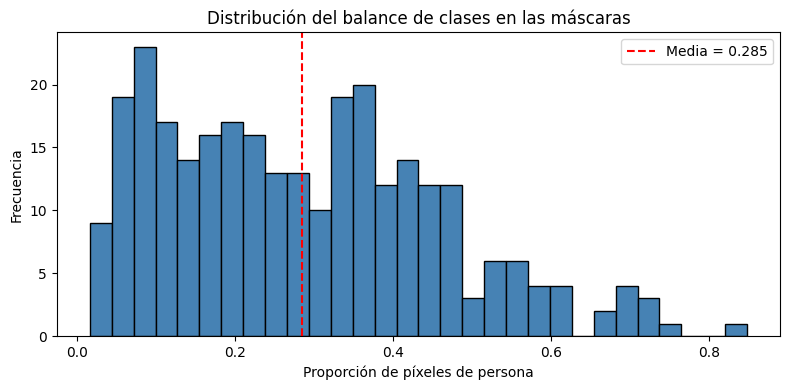

In [4]:
# --- 2.3  Balance de clases (proporción persona vs fondo) ---
fg_ratios = []
for p in tqdm(mask_paths, desc="Analizando máscaras"):
    mask = np.array(Image.open(p).convert("L"))
    fg_ratios.append((mask > 127).sum() / mask.size)

print(f"Proporción media de foreground (persona): {np.mean(fg_ratios):.4f}")
print(f"Proporción media de background (fondo)  : {1 - np.mean(fg_ratios):.4f}")

plt.figure(figsize=(8, 4))
plt.hist(fg_ratios, bins=30, edgecolor="k", color="steelblue")
plt.axvline(np.mean(fg_ratios), color="red", linestyle="--", label=f"Media = {np.mean(fg_ratios):.3f}")
plt.xlabel("Proporción de píxeles de persona")
plt.ylabel("Frecuencia")
plt.title("Distribución del balance de clases en las máscaras")
plt.legend()
plt.tight_layout()
plt.show()

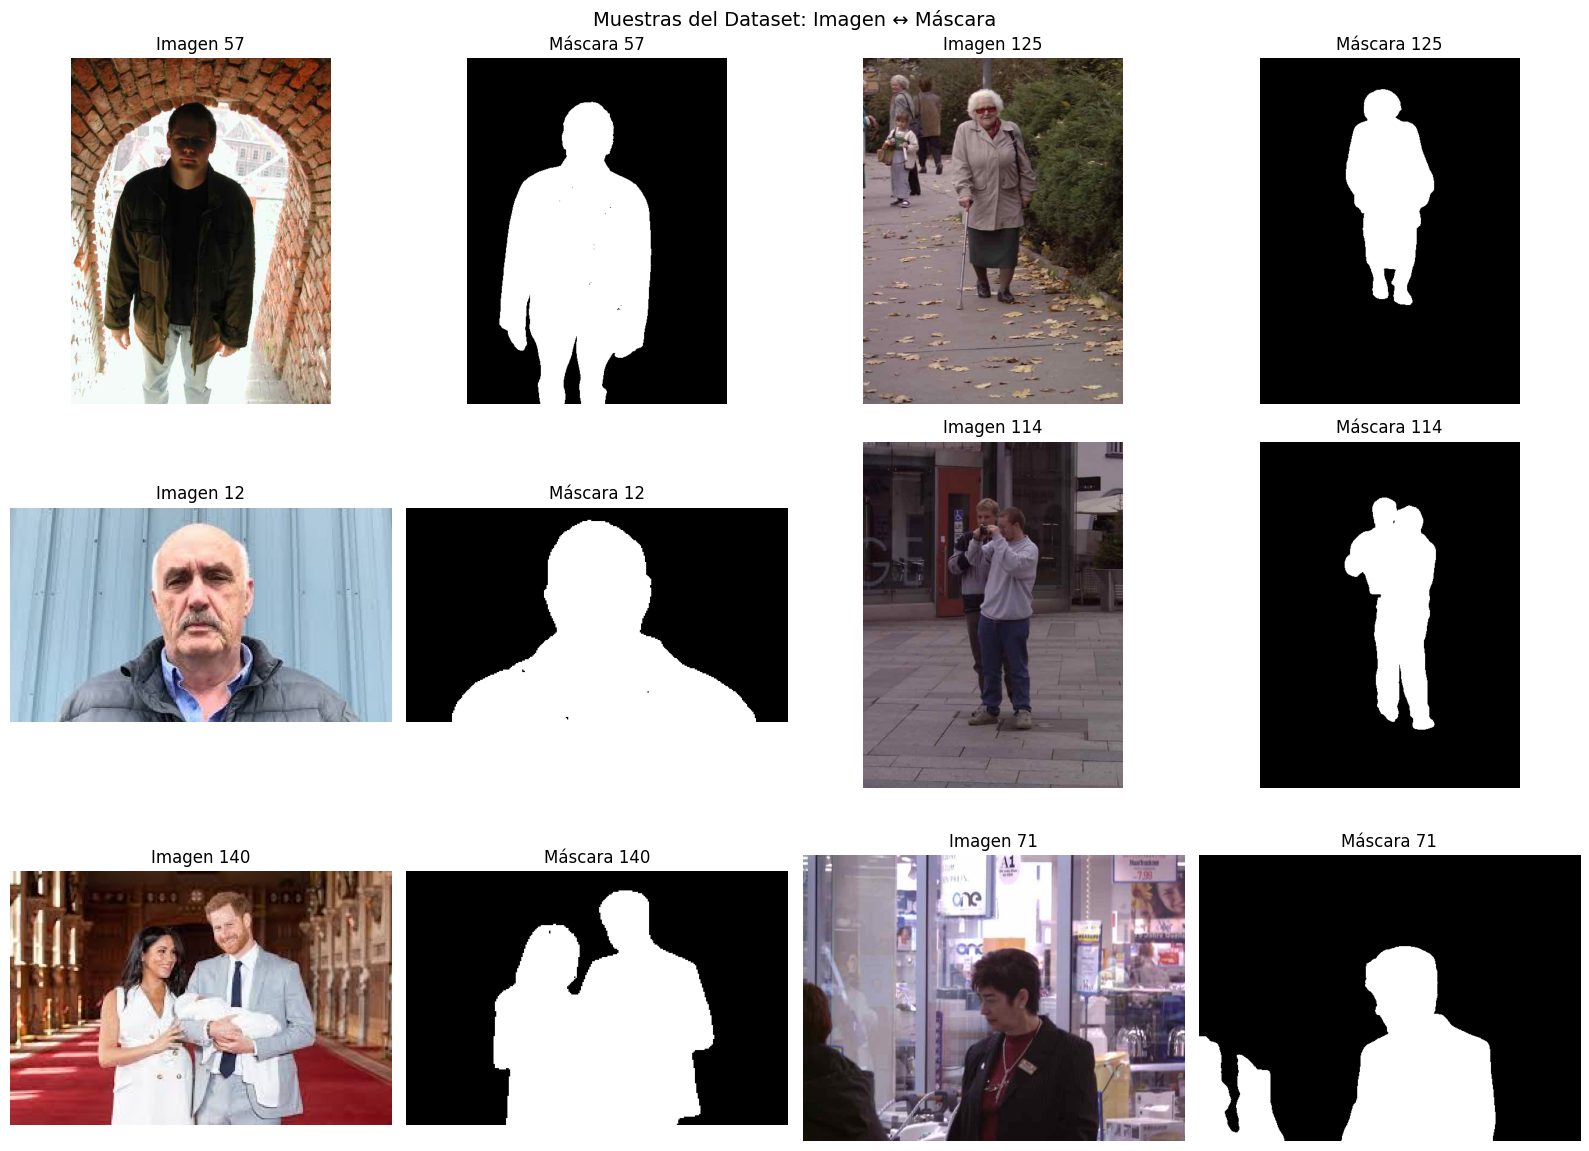

In [5]:
# --- 2.4  Visualización de muestras ---
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
indices = random.sample(range(len(image_paths)), 6)

for row, idx in enumerate(indices[:3]):
    img  = np.array(Image.open(image_paths[idx]))
    mask = np.array(Image.open(mask_paths[idx]).convert("L"))

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"Imagen {idx}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(mask, cmap="gray")
    axes[row, 1].set_title(f"Máscara {idx}")
    axes[row, 1].axis("off")

idx2 = indices[3:]
for row, idx in enumerate(idx2):
    img  = np.array(Image.open(image_paths[idx]))
    mask = np.array(Image.open(mask_paths[idx]).convert("L"))

    axes[row, 2].imshow(img)
    axes[row, 2].set_title(f"Imagen {idx}")
    axes[row, 2].axis("off")

    axes[row, 3].imshow(mask, cmap="gray")
    axes[row, 3].set_title(f"Máscara {idx}")
    axes[row, 3].axis("off")

plt.suptitle("Muestras del Dataset: Imagen ↔ Máscara", fontsize=14)
plt.tight_layout()
plt.show()

---
## 3. Registro de Prompts para la IA

A continuación se documentan los prompts utilizados para obtener asistencia de una IA en la programación de la arquitectura del modelo y otros componentes clave del proyecto.

| # | Prompt | Propósito |
|---|--------|----------|
| 1 | *"Actúa como un Ingeniero de ML. Implementa una arquitectura U-Net en PyTorch para segmentación binaria de personas. La entrada es una imagen RGB de 256×256. La salida debe ser un mapa de 1 canal con activación sigmoide."* | Generar la arquitectura U-Net base |
| 2 | *"Implementa una clase `HumanSegDataset(Dataset)` de PyTorch que cargue pares imagen/máscara, aplique augmentaciones con Albumentations y normalice las imágenes con media y std de ImageNet."* | Crear el Dataset personalizado |
| 3 | *"Escribe un bucle de entrenamiento en PyTorch para segmentación binaria que use BCE + Dice Loss combinada, valide cada época e implemente early stopping. Registra las métricas en listas para graficarlas."* | Bucle de entrenamiento robusto |
| 4 | *"Escribe una función que tome un video MP4, procese cada frame con un modelo de segmentación PyTorch entrenado, aplique la máscara predicha al frame original y guarde el resultado como un nuevo video."* | Inferencia sobre video |
| 5 | *"Calcula las métricas IoU (Intersection over Union) y Dice Score sobre el conjunto de validación para evaluar el rendimiento del modelo de segmentación."* | Evaluación cuantitativa |

> **Nota:** Los prompts anteriores pueden ajustarse según las necesidades específicas que surjan durante el desarrollo.

---
## 4. Hiperparámetros y Configuración del Entrenamiento

In [29]:
# --- Hiperparámetros ---
IMG_SIZE        = 256        # Redimensionar a 256x256
BATCH_SIZE      = 2
NUM_EPOCHS      = 50
LEARNING_RATE   = 1e-4
WEIGHT_DECAY    = 1e-5
VAL_SPLIT       = 0.2       # 80% train, 20% validación
PATIENCE        = 10        # Early stopping
NUM_WORKERS     = 0         # DataLoader workers
PIN_MEMORY      = True if torch.cuda.is_available() else False

---
## 5. Clase `Dataset` Personalizada

Se implementa la clase `HumanSegDataset` que hereda de `torch.utils.data.Dataset`. Esta clase:
- Carga pares (imagen, máscara) desde disco.
- Aplica augmentaciones geométricas y de color mediante **Albumentations**, que garantiza que las mismas transformaciones espaciales se apliquen simultáneamente a la imagen y a su máscara.
- Normaliza las imágenes con la media y desviación estándar de ImageNet.

In [14]:
# --- Transformaciones con Albumentations ---

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.1),
    A.RandomBrightnessContrast(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=15, p=0.4),
    A.GaussianBlur(blur_limit=(3, 7), p=0.2),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2(),
])

In [15]:
class HumanSegDataset(Dataset):
    """
    Dataset personalizado para segmentación de personas.
    
    Parámetros
    ----------
    image_paths : list[str]
        Rutas a las imágenes de entrada (.jpg).
    mask_paths : list[str]
        Rutas a las máscaras ground truth (.png).
    transform : albumentations.Compose, opcional
        Pipeline de augmentaciones/transformaciones.
    """

    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths  = mask_paths
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Cargar imagen en RGB y máscara en escala de grises
        image = np.array(Image.open(self.image_paths[idx]).convert("RGB"))
        mask  = np.array(Image.open(self.mask_paths[idx]).convert("L"), dtype=np.float32)

        # ⚠️ CRÍTICO: Garantizar que imagen y máscara tengan el mismo tamaño
        if image.shape[:2] != mask.shape[:2]:
            img_h, img_w = image.shape[:2]
            mask_h, mask_w = mask.shape[:2]
            # Redimensionar máscara al tamaño de la imagen
            mask = cv2.resize(mask, (img_w, img_h), interpolation=cv2.INTER_NEAREST)

        # Binarizar la máscara: 0 = fondo, 1 = persona
        mask = (mask > 127).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]         # (C, H, W) float32
            mask  = augmented["mask"]           # (H, W) float32

        # Añadir dimensión de canal a la máscara → (1, H, W)
        mask = mask.unsqueeze(0) if isinstance(mask, torch.Tensor) else torch.tensor(mask).unsqueeze(0)

        return image, mask

In [16]:
# --- División train / val ---
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    image_paths, mask_paths, test_size=VAL_SPLIT, random_state=SEED
)

train_dataset = HumanSegDataset(train_imgs, train_masks, transform=train_transform)
val_dataset   = HumanSegDataset(val_imgs,   val_masks,   transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(f"Train: {len(train_dataset)} muestras | Val: {len(val_dataset)} muestras")
print(f"Batches — Train: {len(train_loader)} | Val: {len(val_loader)}")

Train: 232 muestras | Val: 58 muestras
Batches — Train: 29 | Val: 8


In [17]:
# --- DIAGNÓSTICO: Verificar que imágenes y máscaras tengan el mismo tamaño ---
print("[DIAGNÓSTICO] Verificando consistencia de tamaños...")
mismatches = []
for img_path, mask_path in zip(image_paths, mask_paths):
    img = Image.open(img_path)
    mask = Image.open(mask_path)
    if img.size != mask.size:
        mismatches.append((img_path.split("\\")[-1], img.size, mask.size))

if mismatches:
    print(f"⚠ Se encontraron {len(mismatches)} desajustes de tamaño:")
    for fname, img_sz, mask_sz in mismatches[:5]:  # Mostrar primeros 5
        print(f"  {fname}: Imagen {img_sz} vs Máscara {mask_sz}")
else:
    print("✓ Todos los pares imagen-máscara tienen el mismo tamaño")

[DIAGNÓSTICO] Verificando consistencia de tamaños...
⚠ Se encontraron 198 desajustes de tamaño:
  100.jpg: Imagen (1280, 1055) vs Máscara (551, 454)
  101.jpg: Imagen (786, 505) vs Máscara (624, 401)
  105.jpg: Imagen (576, 479) vs Máscara (548, 456)
  107.jpg: Imagen (660, 440) vs Máscara (612, 408)
  108.jpg: Imagen (750, 500) vs Máscara (612, 408)


[LOG] Iniciando carga del batch...
[LOG] Batch cargado en 0.14s
[LOG] Batch imágenes: torch.Size([8, 3, 256, 256])  |  Batch máscaras: torch.Size([8, 1, 256, 256])
[LOG] Creando figura con matplotlib...
[LOG] Figura creada en 0.09s
[LOG] Procesando y dibujando imágenes...
  [IMG 0] Denormalizado en 0.0090s
  [IMG 0] Dibujado en 0.0070s
  [IMG 1] Denormalizado en 0.0030s
  [IMG 1] Dibujado en 0.0040s
  [IMG 2] Denormalizado en 0.0030s
  [IMG 2] Dibujado en 0.0040s
  [IMG 3] Denormalizado en 0.0020s
  [IMG 3] Dibujado en 0.0050s
[LOG] Todas las imágenes procesadas en 0.04s
[LOG] Aplicando formato final...
[LOG] Formato aplicado en 0.09s
[LOG] Mostrando figura...


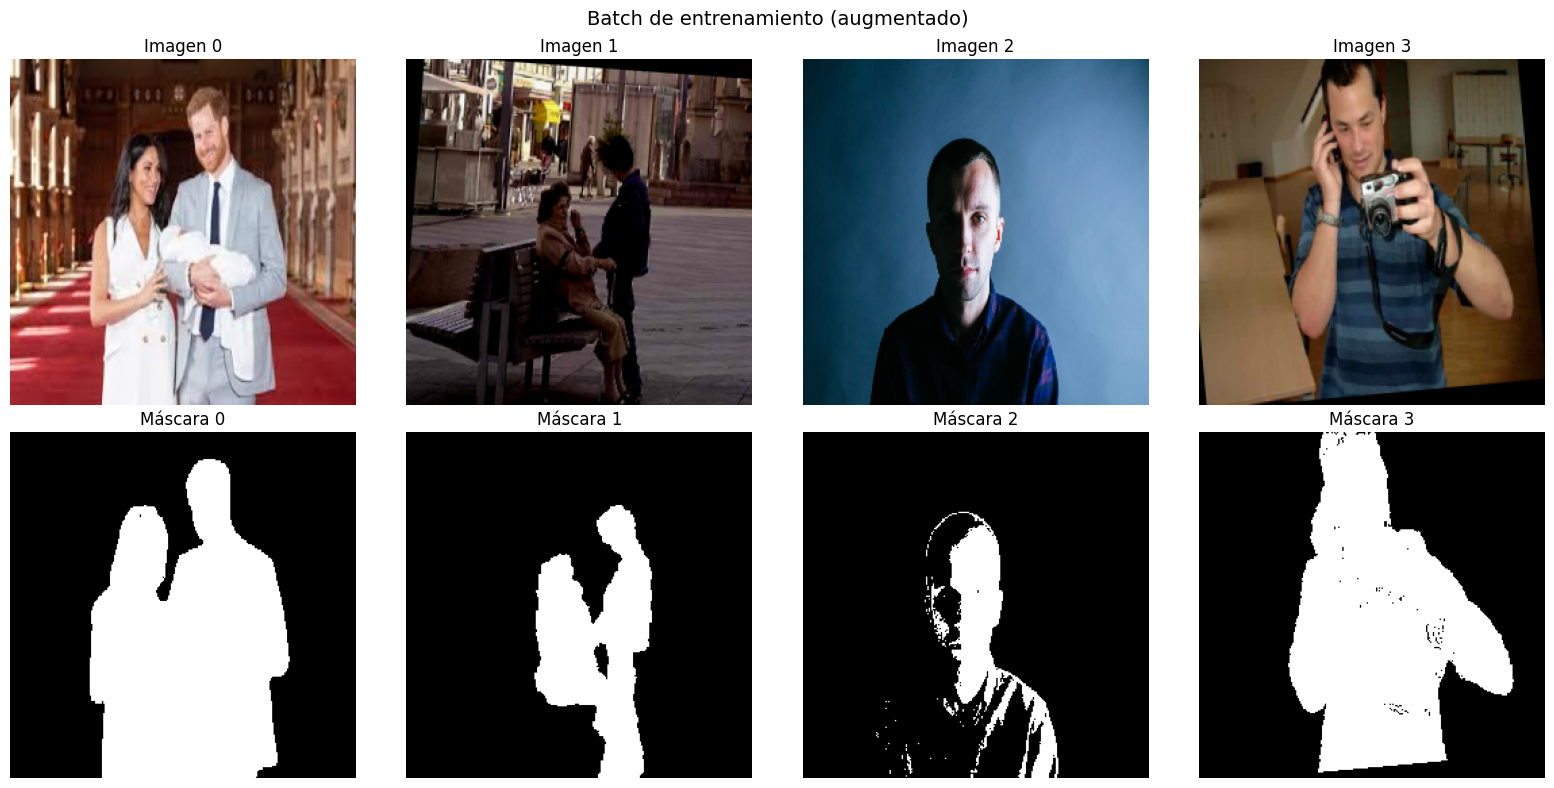

[LOG] ✓ COMPLETADO EN 0.69s TOTALES
  - Carga batch: 0.14s
  - Crear figura: 0.09s
  - Procesar imágenes: 0.04s
  - Formato final: 0.09s
  - Mostrar: 0.34s


In [18]:
import time

# --- Verificación visual de un batch ---
t0 = time.time()
print("[LOG] Iniciando carga del batch...")

batch_imgs, batch_masks = next(iter(train_loader))
t1 = time.time()
print(f"[LOG] Batch cargado en {t1-t0:.2f}s")
print(f"[LOG] Batch imágenes: {batch_imgs.shape}  |  Batch máscaras: {batch_masks.shape}")

print("[LOG] Creando figura con matplotlib...")
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
t2 = time.time()
print(f"[LOG] Figura creada en {t2-t1:.2f}s")

print("[LOG] Procesando y dibujando imágenes...")
for i in range(4):
    t_start = time.time()
    
    # Desnormalizar imagen para visualización
    img = batch_imgs[i].permute(1, 2, 0).numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    
    t_denorm = time.time()
    print(f"  [IMG {i}] Denormalizado en {t_denorm-t_start:.4f}s")

    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Imagen {i}")
    axes[0, i].axis("off")

    axes[1, i].imshow(batch_masks[i].squeeze(), cmap="gray")
    axes[1, i].set_title(f"Máscara {i}")
    axes[1, i].axis("off")
    
    t_draw = time.time()
    print(f"  [IMG {i}] Dibujado en {t_draw-t_denorm:.4f}s")

t3 = time.time()
print(f"[LOG] Todas las imágenes procesadas en {t3-t2:.2f}s")

print("[LOG] Aplicando formato final...")
plt.suptitle("Batch de entrenamiento (augmentado)", fontsize=14)
plt.tight_layout()

t4 = time.time()
print(f"[LOG] Formato aplicado en {t4-t3:.2f}s")

print("[LOG] Mostrando figura...")
plt.show()

t_final = time.time()
print(f"[LOG] ✓ COMPLETADO EN {t_final-t0:.2f}s TOTALES")
print(f"  - Carga batch: {t1-t0:.2f}s")
print(f"  - Crear figura: {t2-t1:.2f}s")
print(f"  - Procesar imágenes: {t3-t2:.2f}s")
print(f"  - Formato final: {t4-t3:.2f}s")
print(f"  - Mostrar: {t_final-t4:.2f}s")

---
## 6. Arquitectura del Modelo: U-Net

Se implementa una **U-Net** clásica (Ronneberger et al., 2015) con las siguientes características:

- **Encoder (contracción):** 4 bloques de doble convolución 3×3 + BatchNorm + ReLU, seguidos de MaxPool 2×2.
- **Bottleneck:** Doble convolución en la resolución más baja.
- **Decoder (expansión):** 4 bloques de ConvTranspose2d 2×2 (up-sampling) + concatenación con skip connections + doble convolución.
- **Capa final:** Conv 1×1 para mapear a 1 canal + activación sigmoide.

La arquitectura usa **skip connections** para preservar información espacial de alta resolución, lo cual es esencial para segmentación precisa de bordes.

In [19]:
class DoubleConv(nn.Module):
    """Bloque de doble convolución: (Conv2d → BN → ReLU) × 2"""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    """
    U-Net para segmentación binaria.

    Parámetros
    ----------
    in_channels : int
        Número de canales de entrada (3 para RGB).
    out_channels : int
        Número de canales de salida (1 para binario).
    features : list[int]
        Número de filtros en cada nivel del encoder.
    """

    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups   = nn.ModuleList()
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)

        # --- Encoder ---
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        # --- Bottleneck ---
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # --- Decoder ---
        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(feature * 2, feature, kernel_size=2, stride=2)
            )
            self.ups.append(DoubleConv(feature * 2, feature))

        # --- Capa de salida ---
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        # Encoder
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]  # invertir para el decoder

        # Decoder
        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x)         # ConvTranspose (upsample)
            skip = skip_connections[i // 2]

            # Ajustar tamaño si es necesario (por entradas no divisibles por 16)
            if x.shape != skip.shape:
                x = nn.functional.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=True)

            x = torch.cat([skip, x], dim=1)  # skip connection
            x = self.ups[i + 1](x)            # DoubleConv

        return torch.sigmoid(self.final_conv(x))

In [20]:
# --- Instanciar modelo y ver resumen ---
model = UNet(in_channels=3, out_channels=1).to(DEVICE)

summary(model, input_size=(1, 3, IMG_SIZE, IMG_SIZE), device=str(DEVICE))

Layer (type:depth-idx)                   Output Shape              Param #
UNet                                     [1, 1, 256, 256]          --
├─ModuleList: 1-7                        --                        (recursive)
│    └─DoubleConv: 2-1                   [1, 64, 256, 256]         --
│    │    └─Sequential: 3-1              [1, 64, 256, 256]         38,848
├─MaxPool2d: 1-2                         [1, 64, 128, 128]         --
├─ModuleList: 1-7                        --                        (recursive)
│    └─DoubleConv: 2-2                   [1, 128, 128, 128]        --
│    │    └─Sequential: 3-2              [1, 128, 128, 128]        221,696
├─MaxPool2d: 1-4                         [1, 128, 64, 64]          --
├─ModuleList: 1-7                        --                        (recursive)
│    └─DoubleConv: 2-3                   [1, 256, 64, 64]          --
│    │    └─Sequential: 3-3              [1, 256, 64, 64]          885,760
├─MaxPool2d: 1-6                         [1,

---
## 7. Función de Pérdida y Optimizador

Para segmentación binaria, se utiliza una **pérdida combinada** que suma:

1. **Binary Cross-Entropy (BCE):** Penaliza errores píxel a píxel de forma independiente.
2. **Dice Loss:** Mide el solapamiento global entre la predicción y la máscara real, siendo más robusta ante desbalance de clases.

$$\mathcal{L}_{total} = \mathcal{L}_{BCE} + \mathcal{L}_{Dice}$$

$$\mathcal{L}_{Dice} = 1 - \frac{2 \sum_{i} p_i g_i + \epsilon}{\sum_{i} p_i + \sum_{i} g_i + \epsilon}$$

In [21]:
class DiceLoss(nn.Module):
    """Dice Loss para segmentación binaria."""

    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds   = preds.view(-1)
        targets = targets.view(-1)
        intersection = (preds * targets).sum()
        dice = (2.0 * intersection + self.smooth) / (preds.sum() + targets.sum() + self.smooth)
        return 1.0 - dice


class BCEDiceLoss(nn.Module):
    """Combinación de BCE + Dice Loss."""

    def __init__(self):
        super().__init__()
        self.bce  = nn.BCELoss()
        self.dice = DiceLoss()

    def forward(self, preds, targets):
        return self.bce(preds, targets) + self.dice(preds, targets)


# --- Instanciar pérdida y optimizador ---
criterion = BCEDiceLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

---
## 8. Métricas de Evaluación

In [25]:
def iou_score(preds, targets, threshold=0.5, smooth=1e-6):
    """
    Intersection over Union (IoU / Jaccard Index).
    """
    preds_bin  = (preds > threshold).float()
    intersection = (preds_bin * targets).sum()
    union = preds_bin.sum() + targets.sum() - intersection
    return ((intersection + smooth) / (union + smooth)).item()


def dice_score(preds, targets, threshold=0.5, smooth=1e-6):
    """
    Dice Coefficient (F1 para segmentación).
    """
    preds_bin  = (preds > threshold).float()
    intersection = (preds_bin * targets).sum()
    return ((2.0 * intersection + smooth) / (preds_bin.sum() + targets.sum() + smooth)).item()


def pixel_accuracy(preds, targets, threshold=0.5):
    """
    Exactitud a nivel de píxel.
    """
    preds_bin = (preds > threshold).float()
    correct = (preds_bin == targets).sum()
    total = targets.numel()
    return (correct / total).item()

---
## 9. Bucle de Entrenamiento

El entrenamiento implementa:
- **Validación por época** con métricas IoU y Dice.
- **Early stopping** si la pérdida de validación no mejora en `PATIENCE` épocas.
- **Guardado del mejor modelo** según la pérdida de validación.
- **Registro de métricas** en listas para visualización posterior.

In [26]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Ejecuta una época de entrenamiento."""
    model.train()
    running_loss = 0.0
    running_iou  = 0.0
    running_dice = 0.0

    for batch_idx, (images, masks) in enumerate(loader):
        t_batch_start = time.time()
        
        print(f"  [Batch {batch_idx}] Transfiriendo a {device}...", end=" ")
        images = images.to(device)
        masks  = masks.to(device)
        print(f"✓ ({time.time() - t_batch_start:.2f}s)")

        # Forward
        print(f"  [Batch {batch_idx}] Forward pass...", end=" ")
        t_forward = time.time()
        preds = model(images)
        print(f"✓ ({time.time() - t_forward:.2f}s)")
        
        print(f"  [Batch {batch_idx}] Calculando pérdida...", end=" ")
        t_loss = time.time()
        loss  = criterion(preds, masks)
        print(f"✓ ({time.time() - t_loss:.2f}s)")

        # Backward
        print(f"  [Batch {batch_idx}] Backward pass...", end=" ")
        t_backward = time.time()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        print(f"✓ ({time.time() - t_backward:.2f}s)")

        running_loss += loss.item()
        running_iou  += iou_score(preds, masks)
        running_dice += dice_score(preds, masks)
        
        print(f"  [Batch {batch_idx}] COMPLETO en {time.time() - t_batch_start:.2f}s | Loss: {loss.item():.4f}\n")

    n = len(loader)
    return running_loss / n, running_iou / n, running_dice / n


@torch.no_grad()
def validate(model, loader, criterion, device):
    """Ejecuta la validación."""
    model.eval()
    running_loss = 0.0
    running_iou  = 0.0
    running_dice = 0.0

    for batch_idx, (images, masks) in enumerate(loader):
        print(f"  [Val Batch {batch_idx}] Transfiriendo...", end=" ")
        images = images.to(device)
        masks  = masks.to(device)
        print(f"✓")

        print(f"  [Val Batch {batch_idx}] Forward pass...", end=" ")
        preds = model(images)
        print(f"✓")
        
        loss  = criterion(preds, masks)

        running_loss += loss.item()
        running_iou  += iou_score(preds, masks)
        running_dice += dice_score(preds, masks)

    n = len(loader)
    return running_loss / n, running_iou / n, running_dice / n

In [30]:
# --- PRE-ENTRENAMIENTO: Verificación y prueba de velocidad ---
print("=" * 70)
print("VERIFICACIÓN PRE-ENTRENAMIENTO")
print("=" * 70)

# Verificar GPU
if torch.cuda.is_available():
    print(f"✓ GPU detectada: {torch.cuda.get_device_name(0)}")
    print(f"  CUDA Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f}GB")
else:
    print("⚠ GPU NO DISPONIBLE - Usando CPU (será MÁS LENTO)")

# Contar parámetros del modelo
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n📊 Modelo U-Net:")
print(f"  Total parámetros: {total_params:,}")
print(f"  Parámetros entrenable: {trainable_params:,}")

# Test de velocidad: Forward pass en un batch
print(f"\n⏱ Test de velocidad (1 forward pass):")
test_batch_imgs, test_batch_masks = next(iter(train_loader))
test_batch_imgs = test_batch_imgs.to(DEVICE)

t_test = time.time()
with torch.no_grad():
    _ = model(test_batch_imgs)
t_test = time.time() - t_test

print(f"  Forward pass (batch_size={BATCH_SIZE}, img_size={IMG_SIZE}x{IMG_SIZE}): {t_test:.2f}s")
if t_test > 2:
    print(f"  ⚠ ADVERTENCIA: Forward pass muy lenta. Considera:")
    print(f"     - Reducir BATCH_SIZE (actual: {BATCH_SIZE})")
    print(f"     - Verificar que GPU esté en uso")
else:
    print(f"  ✓ Velocidad aceptable")

print("\n" + "=" * 70)

VERIFICACIÓN PRE-ENTRENAMIENTO
⚠ GPU NO DISPONIBLE - Usando CPU (será MÁS LENTO)

📊 Modelo U-Net:
  Total parámetros: 31,037,633
  Parámetros entrenable: 31,037,633

⏱ Test de velocidad (1 forward pass):
  Forward pass (batch_size=2, img_size=256x256): 2.87s
  ⚠ ADVERTENCIA: Forward pass muy lenta. Considera:
     - Reducir BATCH_SIZE (actual: 2)
     - Verificar que GPU esté en uso



In [31]:
# --- Entrenamiento con Early Stopping ---
print("=" * 70)
print("INICIANDO ENTRENAMIENTO")
print(f"Device: {DEVICE}")
print(f"Batch size: {BATCH_SIZE} | Total batches por época: {len(train_loader)}")
print(f"Hiperparámetros: LR={LEARNING_RATE}, WeightDecay={WEIGHT_DECAY}")
print("=" * 70)

history = {
    "train_loss": [], "val_loss": [],
    "train_iou": [],  "val_iou": [],
    "train_dice": [], "val_dice": [],
}

best_val_loss = float("inf")
patience_counter = 0
best_model_path = os.path.join(MODEL_DIR, "unet_best.pth")

try:
    for epoch in range(1, NUM_EPOCHS + 1):
        print(f"\n[ÉPOCA {epoch:02d}/{NUM_EPOCHS}] Iniciando...")
        t_epoch = time.time()
        
        print("  → Entrenamiento:")
        train_loss, train_iou, train_dice = train_one_epoch(
            model, train_loader, criterion, optimizer, DEVICE
        )
        
        print("  → Validación:")
        val_loss, val_iou, val_dice = validate(
            model, val_loader, criterion, DEVICE
        )

        # Registrar métricas
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_iou"].append(train_iou)
        history["val_iou"].append(val_iou)
        history["train_dice"].append(train_dice)
        history["val_dice"].append(val_dice)

        print(
            f"\n[ÉPOCA {epoch:02d}] ✓ Completada en {time.time() - t_epoch:.1f}s"
            f"\n  Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} "
            f"| Train IoU: {train_iou:.4f} | Val IoU: {val_iou:.4f}"
        )

        # Early stopping & guardado del mejor modelo
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), best_model_path)
            print(f"  → MEJOR MODELO guardado (val_loss: {val_loss:.4f}) ⭐")
        else:
            patience_counter += 1
            print(f"  → Sin mejora ({patience_counter}/{PATIENCE})")
            if patience_counter >= PATIENCE:
                print(f"\n⏹ EARLY STOPPING en la época {epoch} (sin mejora en {PATIENCE} épocas).")
                break

except KeyboardInterrupt:
    print("\n\n⚠ ENTRENAMIENTO INTERRUMPIDO POR EL USUARIO")
except Exception as e:
    print(f"\n\n❌ ERROR DURANTE ENTRENAMIENTO: {e}")
    raise

print(f"\n✓ Entrenamiento finalizado.")
print(f"  Mejor modelo guardado en: {best_model_path}")
print(f"  Total de épocas completadas: {len(history['train_loss'])}")

INICIANDO ENTRENAMIENTO
Device: cpu
Batch size: 2 | Total batches por época: 29
Hiperparámetros: LR=0.0001, WeightDecay=1e-05

[ÉPOCA 01/50] Iniciando...
  → Entrenamiento:
  [Batch 0] Transfiriendo a cpu... ✓ (0.00s)
  [Batch 0] Forward pass... ✓ (2.67s)
  [Batch 0] Calculando pérdida... ✓ (0.01s)
  [Batch 0] Backward pass... ✓ (6.67s)
  [Batch 0] COMPLETO en 9.35s | Loss: 1.1949

  [Batch 1] Transfiriendo a cpu... ✓ (0.00s)
  [Batch 1] Forward pass... ✓ (3.41s)
  [Batch 1] Calculando pérdida... ✓ (0.00s)
  [Batch 1] Backward pass... ✓ (6.99s)
  [Batch 1] COMPLETO en 10.40s | Loss: 1.2079

  [Batch 2] Transfiriendo a cpu... ✓ (0.00s)
  [Batch 2] Forward pass... ✓ (3.72s)
  [Batch 2] Calculando pérdida... ✓ (0.00s)
  [Batch 2] Backward pass... ✓ (6.95s)
  [Batch 2] COMPLETO en 10.68s | Loss: 1.2912

  [Batch 3] Transfiriendo a cpu... ✓ (0.00s)
  [Batch 3] Forward pass... ✓ (3.67s)
  [Batch 3] Calculando pérdida... ✓ (0.00s)
  [Batch 3] Backward pass... ✓ (7.23s)
  [Batch 3] COMPLETO en

---
## 10. Visualización de Curvas de Entrenamiento

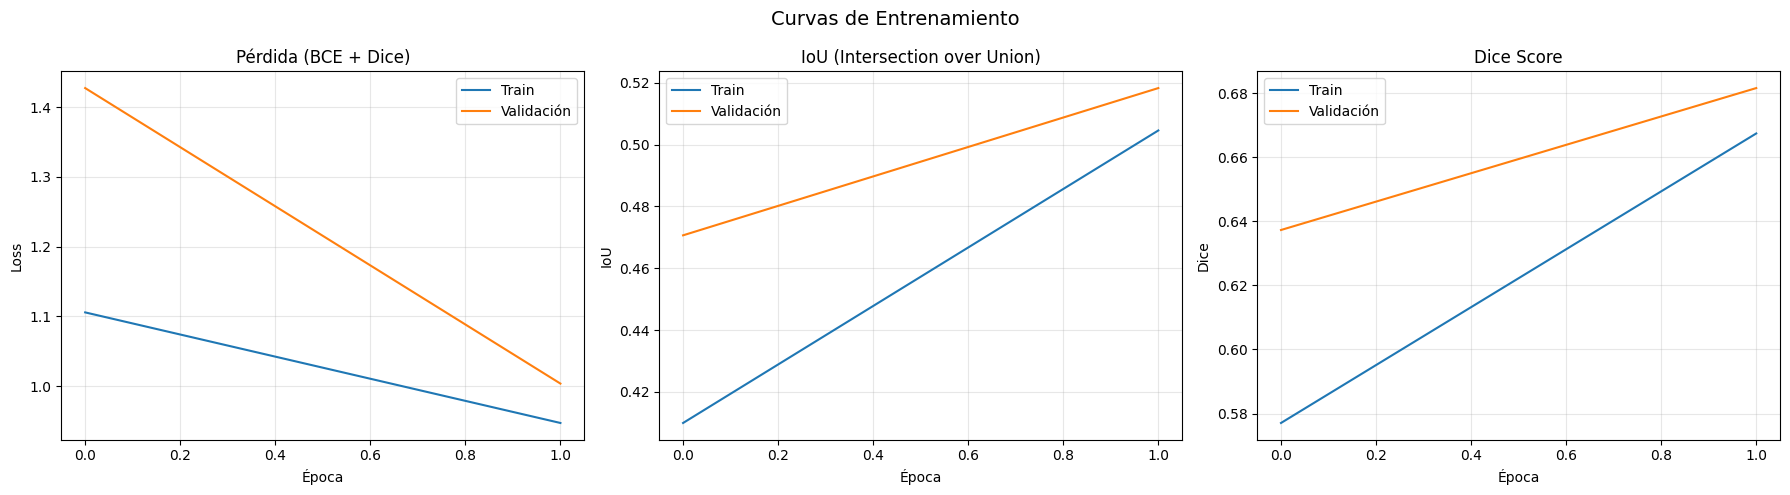

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Validación")
axes[0].set_title("Pérdida (BCE + Dice)")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# IoU
axes[1].plot(history["train_iou"], label="Train")
axes[1].plot(history["val_iou"], label="Validación")
axes[1].set_title("IoU (Intersection over Union)")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("IoU")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Dice
axes[2].plot(history["train_dice"], label="Train")
axes[2].plot(history["val_dice"], label="Validación")
axes[2].set_title("Dice Score")
axes[2].set_xlabel("Época")
axes[2].set_ylabel("Dice")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle("Curvas de Entrenamiento", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "samples", "curvas_entrenamiento.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 11. Evaluación Cualitativa en el Conjunto de Validación

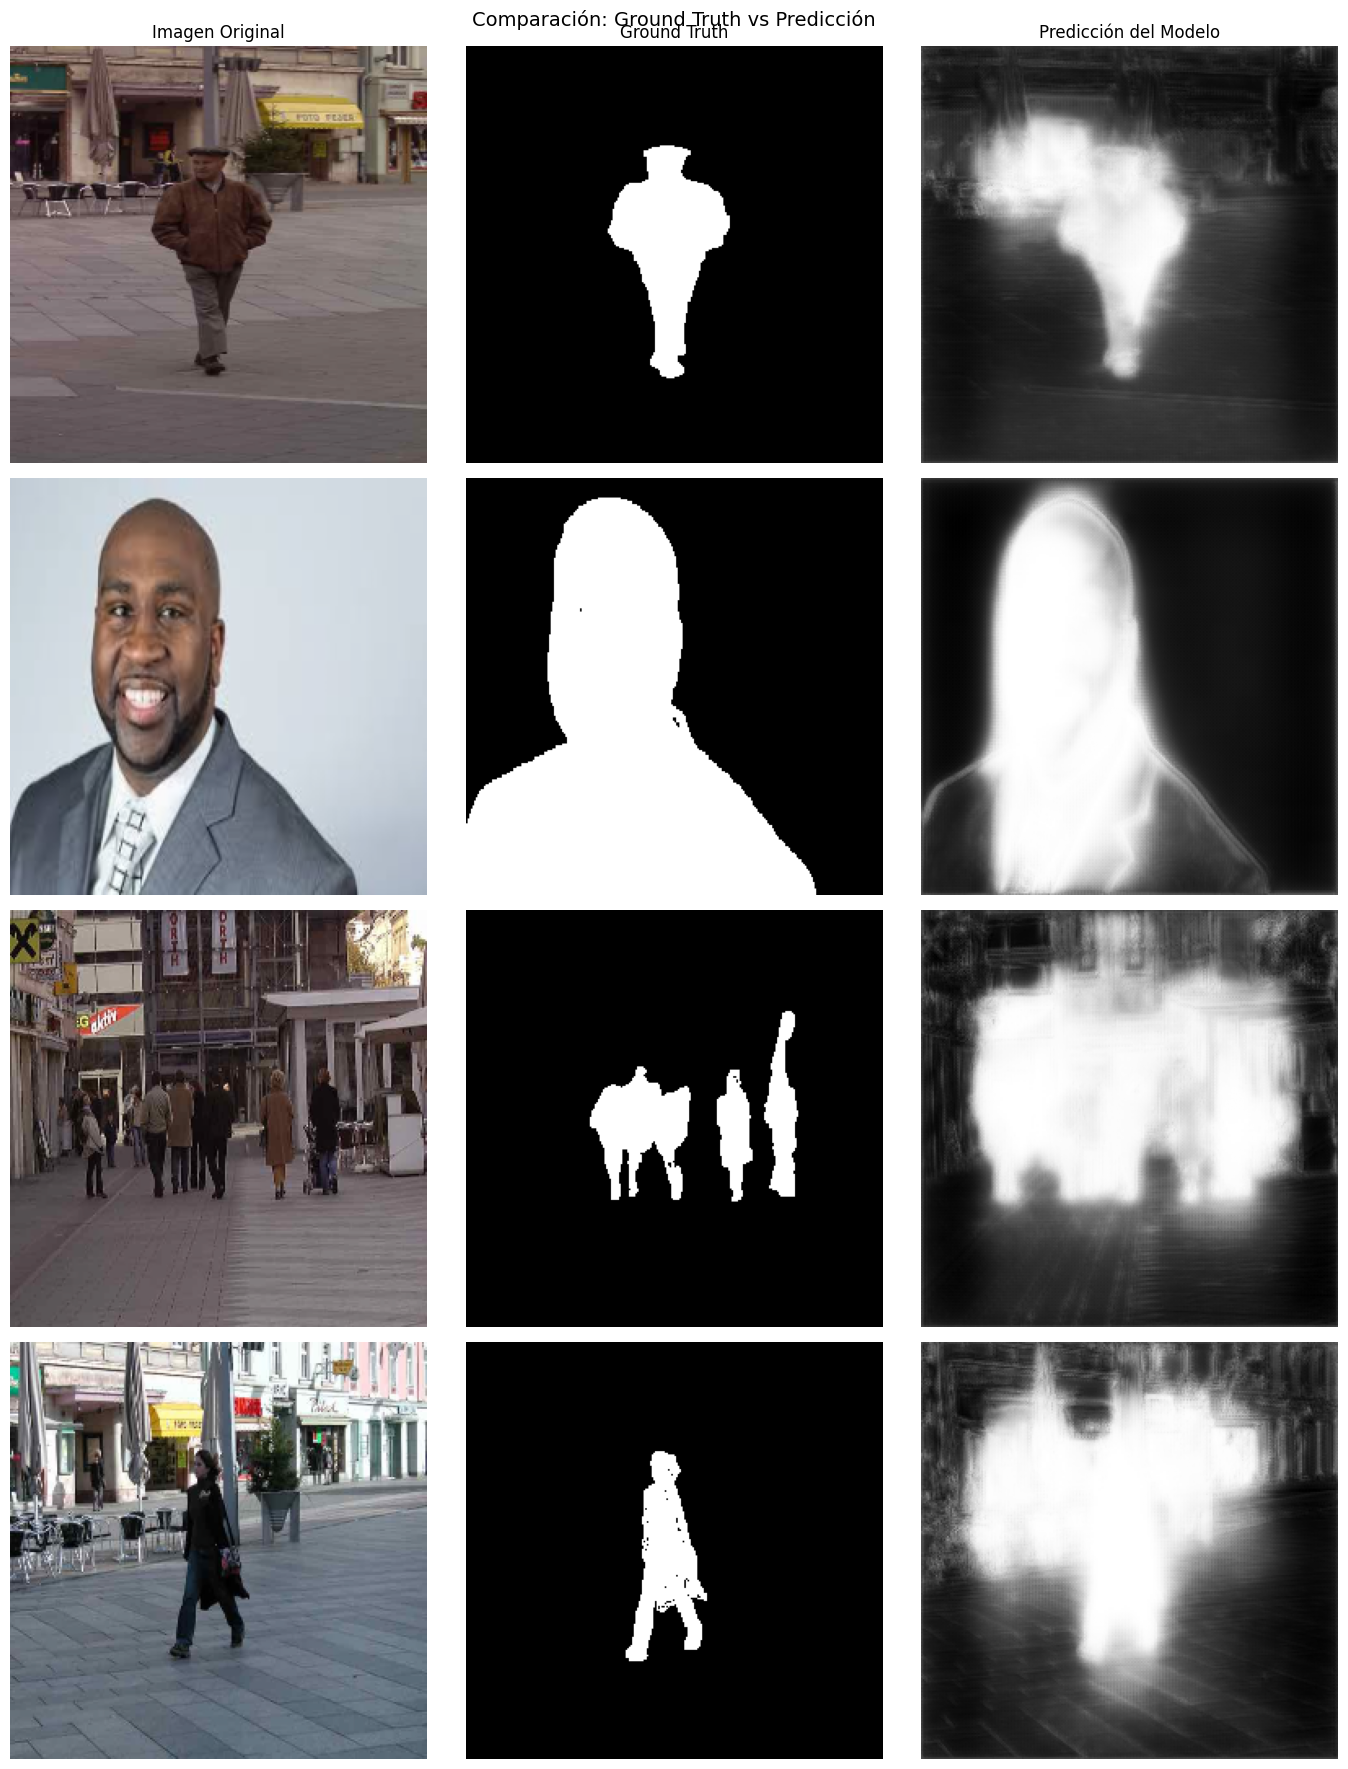

In [33]:
# --- Cargar el mejor modelo ---
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

# --- Predicciones sobre muestras de validación ---
fig, axes = plt.subplots(4, 3, figsize=(14, 18))
axes[0, 0].set_title("Imagen Original", fontsize=12)
axes[0, 1].set_title("Ground Truth", fontsize=12)
axes[0, 2].set_title("Predicción del Modelo", fontsize=12)

val_indices = random.sample(range(len(val_dataset)), 4)

for row, idx in enumerate(val_indices):
    img_tensor, mask_tensor = val_dataset[idx]

    # Predicción
    with torch.no_grad():
        pred = model(img_tensor.unsqueeze(0).to(DEVICE)).cpu().squeeze()

    # Desnormalizar imagen
    img_np = img_tensor.permute(1, 2, 0).numpy()
    img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_np = np.clip(img_np, 0, 1)

    axes[row, 0].imshow(img_np)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(mask_tensor.squeeze(), cmap="gray")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(pred.numpy(), cmap="gray")
    axes[row, 2].axis("off")

plt.suptitle("Comparación: Ground Truth vs Predicción", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "samples", "predicciones_validacion.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 12. Evaluación Cuantitativa Final en Validación

In [34]:
# --- Métricas finales sobre todo el conjunto de validación ---
all_iou, all_dice, all_acc = [], [], []

model.eval()
with torch.no_grad():
    for images, masks in tqdm(val_loader, desc="Evaluando"):
        images = images.to(DEVICE)
        masks  = masks.to(DEVICE)
        preds  = model(images)

        all_iou.append(iou_score(preds, masks))
        all_dice.append(dice_score(preds, masks))
        all_acc.append(pixel_accuracy(preds, masks))

print("=" * 50)
print("MÉTRICAS FINALES EN VALIDACIÓN")
print("=" * 50)
print(f"  IoU  (Jaccard)       : {np.mean(all_iou):.4f} ± {np.std(all_iou):.4f}")
print(f"  Dice (F1)            : {np.mean(all_dice):.4f} ± {np.std(all_dice):.4f}")
print(f"  Pixel Accuracy       : {np.mean(all_acc):.4f} ± {np.std(all_acc):.4f}")
print("=" * 50)

Evaluando:   0%|          | 0/8 [00:00<?, ?it/s]

MÉTRICAS FINALES EN VALIDACIÓN
  IoU  (Jaccard)       : 0.5183 ± 0.0457
  Dice (F1)            : 0.6815 ± 0.0387
  Pixel Accuracy       : 0.7882 ± 0.0433


---
## 13. Inferencia sobre Video

Se procesa un video corto (~10 segundos) frame por frame:
1. Se lee cada frame con OpenCV.
2. Se aplica la misma normalización que en validación.
3. Se pasa por el modelo para obtener la máscara predicha.
4. Se aplica la máscara al frame original (efecto de segmentación).
5. Se guarda el resultado como un nuevo video MP4.

> **Instrucción:** Coloca tu video de prueba (`.mp4`) en la carpeta `videos/` antes de ejecutar esta celda.

In [ ]:
def process_video(model, input_path, output_path, device, img_size=256):
    """
    Procesa un video frame por frame con el modelo de segmentación.
    
    Genera un video de salida con tres paneles: original | máscara | segmentado.
    
    Parámetros
    ----------
    model : nn.Module
        Modelo de segmentación entrenado.
    input_path : str
        Ruta al video de entrada.
    output_path : str
        Ruta donde se guardará el video procesado.
    device : torch.device
        Dispositivo de cómputo.
    img_size : int
        Tamaño al que se redimensionará cada frame para la inferencia.
    """
    model.eval()
    cap = cv2.VideoCapture(input_path)

    if not cap.isOpened():
        print(f"Error: No se pudo abrir el video '{input_path}'")
        return

    fps    = int(cap.get(cv2.CAP_PROP_FPS))
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    print(f"Video de entrada: {width}x{height} @ {fps} FPS, {total} frames")

    # El video de salida tendrá 3 paneles lado a lado
    out_width = width * 3
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(output_path, fourcc, fps, (out_width, height))

    # Transformaciones (mismas que validación, sin ToTensor ya que usaremos cv2)
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    with torch.no_grad():
        for i in tqdm(range(total), desc="Procesando video"):
            ret, frame = cap.read()
            if not ret:
                break

            # Preparar frame para el modelo
            frame_rgb   = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            resized     = cv2.resize(frame_rgb, (img_size, img_size))
            normalized  = (resized / 255.0 - mean) / std
            tensor      = torch.from_numpy(normalized.transpose(2, 0, 1)).float().unsqueeze(0).to(device)

            # Inferencia
            pred_mask = model(tensor).cpu().squeeze().numpy()
            pred_mask = (pred_mask > 0.5).astype(np.uint8) * 255

            # Redimensionar máscara al tamaño original
            mask_full = cv2.resize(pred_mask, (width, height), interpolation=cv2.INTER_NEAREST)

            # Crear máscara de 3 canales para operaciones de enmascaramiento
            mask_3ch = cv2.cvtColor(mask_full, cv2.COLOR_GRAY2BGR)

            # Aplicar máscara: persona sobre fondo oscuro
            segmented = cv2.bitwise_and(frame, mask_3ch)

            # Crear visualización de la máscara coloreada (rojo)
            mask_vis = np.zeros_like(frame)
            mask_vis[:, :, 2] = mask_full  # canal rojo
            mask_overlay = cv2.addWeighted(frame, 0.6, mask_vis, 0.4, 0)

            # Concatenar paneles: original | máscara overlay | segmentado
            combined = np.hstack([frame, mask_overlay, segmented])
            out.write(combined)

    cap.release()
    out.release()
    print(f"Video guardado en: {output_path}")

In [ ]:
# --- Ejecutar inferencia sobre video ---
# INSTRUCCIÓN: Cambia el nombre del archivo por el de tu video de prueba
INPUT_VIDEO  = os.path.join(VIDEO_DIR, "test_video.mp4")
OUTPUT_VIDEO = os.path.join(OUTPUT_DIR, "videos", "resultado_segmentacion.mp4")

if os.path.exists(INPUT_VIDEO):
    process_video(model, INPUT_VIDEO, OUTPUT_VIDEO, DEVICE, img_size=IMG_SIZE)
else:
    print(f"⚠ No se encontró el video de entrada: {INPUT_VIDEO}")
    print("  Coloca un video .mp4 de ~10 segundos en la carpeta 'videos/' y ejecuta de nuevo.")

---
## 14. Conclusiones

### Rendimiento del Modelo

*(Completa esta sección después del entrenamiento con los resultados reales)*

- **IoU obtenido en validación:** _X.XXXX_
- **Dice Score en validación:** _X.XXXX_
- **Pixel Accuracy:** _X.XXXX_

### Observaciones

1. **Calidad de la segmentación:** _(Describir si el modelo detecta correctamente los contornos de las personas, si tiene problemas con fondos complejos, etc.)_

2. **Efecto de las augmentaciones:** _(Comentar si las augmentaciones ayudaron a generalizar, si hubo overfitting, etc.)_

3. **Pérdida combinada BCE + Dice:** _(Comentar la contribución de cada componente de la pérdida.)_

4. **Rendimiento en video:** _(Describir la calidad de la segmentación en tiempo real vs imágenes estáticas.)_

5. **Limitaciones detectadas:**
   - _(Ej. personas parcialmente ocultas, fondos similares al tono de piel, etc.)_

### Mejoras Futuras

- Utilizar un encoder preentrenado (e.g., ResNet-34) como backbone del U-Net.
- Experimentar con arquitecturas más avanzadas (DeepLabV3+, SegFormer).
- Aumentar el dataset con técnicas de augmentación más agresivas.
- Implementar post-procesamiento con CRF (Conditional Random Fields).
- Optimizar para inferencia en tiempo real con TorchScript o ONNX.

---

**Fin del informe.**